# Non-pregnant anemia prevalence and DALYs averted by fortification

We take a "multiplication model" approach here, shifting continuous hemoglobin (as estimated
by GBD) and seeing what impact that has on anemia.

It's important to note that we directly use hemoglobin estimates, which are the first step
of the GBD anemia estimation pipeline. The risks and causes that are related to anemia are
all calculated downstream from this.

In [1]:
import gbd_mapping
import risk_distributions
import pathlib
import pandas as pd, numpy as np
import vivarium_inputs
from vivarium_inputs import utility_data, globals as vi_globals, utilities as vi_utils
from vivarium_gbd_access import gbd
import os, contextlib, warnings, loguru
from lsff_utils import config_utils
from lsff_utils.hemoglobin_distribution import hemoglobin_cdf_from_mean_sd

from vivarium_inputs.validation.raw import DataDoesNotExistError, DataAbnormalError
from tqdm.notebook import tqdm

Config: 'input_data:
    cache_data:
        base: True
    intermediary_data_cache_path:
        base: /share/scratch/users/{username}/cache'
Cache Dir: '/share/scratch/users/zmbc/cache'


In [2]:
pd.set_option("display.max_columns", 30)

In [3]:
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [4]:
location = "india"
vehicle = "rice"

In [5]:
# Parameters
location = "india"
vehicle = "rice"


In [6]:
intervention_scenarios = config_utils.get_config()["custom_intervention_scenarios"].get(location, ["intervention"])
intervention_scenarios

['intervention']

## Setup and scenarios

In [7]:
index_cols = ["sex", "age_start", "age_end", "wealth_quintile"]

age_group_ids = [
    2,
    3,
    388,
    389,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    30,
    31,
    32,
    235,
]
sex_ids = [1, 2]

DRAWS = [
    f"draw_{i}" for i in range(500)
]  # NOTE: Some GBD 2021 things return 1,000 but others don't

In [8]:
effective_coverage_baseline = pd.read_csv(
    f"../0100_data_prep/results/iron/{vehicle}/baseline_fortification/effective_coverage/{location}.csv"
)
assert (effective_coverage_baseline.vehicle_name == vehicle).all()
effective_coverage_baseline = effective_coverage_baseline.drop(columns=["vehicle_name"])
effective_coverage_baseline

,wealth_quintile,sex,age_start,age_end,value
0,1,Female,0,5,0.294750
1,1,Female,5,15,0.384923
2,1,Female,15,30,0.340118
3,1,Female,30,50,0.367724
4,1,Female,50,125,0.384701
5,1,Male,0,5,0.301125
6,1,Male,5,15,0.388070
7,1,Male,15,30,0.361587
8,1,Male,30,50,0.354325
9,1,Male,50,125,0.379405


In [9]:
def expand(df):
    for col in sorted(list(set(df.columns) - {"value"})):
        if df[col].isnull().any():
            df = pd.concat(
                [
                    df[df[col].notnull()],
                    *[
                        df[df[col].isnull()].assign(**{col: value})
                        for value in df[df[col].notnull()][col].unique()
                    ],
                ]
            )

    return df

In [10]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_baseline.columns:
        effective_coverage_baseline[col] = fill_value
    else:
        effective_coverage_baseline[col] = effective_coverage_baseline[col].fillna(
            fill_value
        )

In [11]:
effective_coverage_baseline = expand(effective_coverage_baseline)
effective_coverage_baseline

,wealth_quintile,sex,age_start,age_end,value
0,1,Female,0,5,0.294750
1,1,Female,5,15,0.384923
2,1,Female,15,30,0.340118
3,1,Female,30,50,0.367724
4,1,Female,50,125,0.384701
5,1,Male,0,5,0.301125
6,1,Male,5,15,0.388070
7,1,Male,15,30,0.361587
8,1,Male,30,50,0.354325
9,1,Male,50,125,0.379405


In [12]:
effective_coverage_intervention = pd.concat([
    pd.read_csv(
        f"../0100_data_prep/results/iron/{vehicle}/{intervention_scenario}/intervention_fortification/effective_coverage/{location}.csv"
    ).assign(scenario=intervention_scenario)
    for intervention_scenario in intervention_scenarios
])
assert (effective_coverage_intervention.vehicle_name == vehicle).all()
effective_coverage_intervention = effective_coverage_intervention.drop(
    columns=["vehicle_name"]
)
effective_coverage_intervention

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0,5,1,0.480408,intervention
1,Female,0,5,2,0.489627,intervention
2,Female,0,5,3,0.485258,intervention
3,Female,0,5,4,0.465105,intervention
4,Female,0,5,5,0.414790,intervention
5,Female,5,15,1,0.518085,intervention
6,Female,5,15,2,0.516195,intervention
7,Female,5,15,3,0.503735,intervention
8,Female,5,15,4,0.480685,intervention
9,Female,5,15,5,0.422331,intervention


In [13]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_intervention.columns:
        effective_coverage_intervention[col] = fill_value
    else:
        effective_coverage_intervention[col] = effective_coverage_intervention[
            col
        ].fillna(fill_value)

In [14]:
effective_coverage_intervention = expand(effective_coverage_intervention)
effective_coverage_intervention

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0,5,1,0.480408,intervention
1,Female,0,5,2,0.489627,intervention
2,Female,0,5,3,0.485258,intervention
3,Female,0,5,4,0.465105,intervention
4,Female,0,5,5,0.414790,intervention
5,Female,5,15,1,0.518085,intervention
6,Female,5,15,2,0.516195,intervention
7,Female,5,15,3,0.503735,intervention
8,Female,5,15,4,0.480685,intervention
9,Female,5,15,5,0.422331,intervention


In [15]:
population = pd.read_csv(
    f"../0100_data_prep/results/population/stratified/{location}.csv"
)

In [16]:
non_pregnant_pop = population.pipe(lambda df: df[df.pregnant == "not_pregnant"]).drop(
    columns="pregnant"
)
non_pregnant_pop = non_pregnant_pop.set_index(
    [c for c in non_pregnant_pop.columns if c != "value"]
).value
non_pregnant_pop

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  49649.700497
                               2                  43575.622144
                               3                  38689.356750
                               4                  36440.833935
                               5                  29202.585338
                                                      ...     
Male    95.0       125.000000  1                  15176.692284
                               2                  15848.509818
                               3                  16370.176208
                               4                  17265.313670
                               5                  21289.473456
Name: value, Length: 250, dtype: float64

In [17]:
population.set_index(["sex", "age_start", "age_end"]).loc[
    ("Female", 25, 30)
].value.sum()

59874947.231616504

In [18]:
non_pregnant_pop.loc[("Female", 25, 30)][1]

9317439.611504933

In [19]:
non_pregnant_pop.loc[("Female", 25, 30)].sum()

52388289.46165088

In [20]:
population_age_groups = (
    non_pregnant_pop.reset_index()[["age_start", "age_end"]]
    .drop_duplicates()
    .sort_values("age_start")
)
population_age_groups

,age_start,age_end
0,0.000000,0.019178
5,0.019178,0.076712
10,0.076712,0.500000
15,0.500000,1.000000
20,1.000000,2.000000
25,2.000000,5.000000
30,5.000000,10.000000
35,10.000000,15.000000
40,15.000000,20.000000
45,20.000000,25.000000


In [21]:
def map_to_population_age_groups(df):
    result = (
        population_age_groups.merge(df, how="cross", suffixes=("", "_orig"))
        .pipe(
            lambda df: df[
                (df.age_end <= df.age_end_orig) & (df.age_start >= df.age_start_orig)
            ]
        )
        .drop(columns=["age_start_orig", "age_end_orig"])
    )
    return result

In [22]:
effective_coverage_baseline = (
    map_to_population_age_groups(effective_coverage_baseline)
    .set_index([c for c in effective_coverage_baseline.columns if c != "value"])
    .value
)
effective_coverage_intervention = (
    map_to_population_age_groups(effective_coverage_intervention)
    .set_index([c for c in effective_coverage_intervention.columns if c != "value"])
    .value
)

In [23]:
if "sex" not in effective_coverage_baseline.index.names:
    # Assume does not vary
    effective_coverage_baseline = pd.concat(
        [
            effective_coverage_baseline.reset_index()
            .assign(sex="Female")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
            effective_coverage_baseline.reset_index()
            .assign(sex="Male")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
        ]
    )

In [24]:
effective_coverage_baseline = (
    effective_coverage_baseline.reset_index()
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)

In [25]:
if "sex" not in effective_coverage_intervention.index.names:
    # Assume does not vary
    effective_coverage_intervention = pd.concat(
        [
            effective_coverage_intervention.reset_index()
            .assign(sex="Female")
            .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
            effective_coverage_intervention.reset_index()
            .assign(sex="Male")
            .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
        ]
    )

In [26]:
effective_coverage_intervention = (
    effective_coverage_intervention.reset_index()
    # TODO: Make this clearer. This is just reordering.
    .set_index(["sex", "age_start", "age_end", "wealth_quintile", "scenario"])
    .value
)

In [27]:
example_sex = "Female"
example_age_start = 25
example_age_end = 30
example_wealth_quintile = 1
example_scenario = effective_coverage_intervention.index.get_level_values("scenario")[0]
example_tuple = (example_sex, example_age_start, example_age_end, example_wealth_quintile)

In [28]:
effective_coverage_baseline.loc[example_tuple]

0.3401179170826516

In [29]:
effective_coverage_intervention.loc[example_tuple]

scenario
intervention    0.490003
Name: value, dtype: float64

In [30]:
def reshape_to_vivarium_format(df, location):
    df = vi_utils.reshape(df, value_cols=[c for c in df.columns if "draw_" in c])
    df = vi_utils.scrub_gbd_conventions(df, location)
    df = vi_utils.split_interval(df, interval_column="age", split_column_prefix="age")
    df = vi_utils.split_interval(df, interval_column="year", split_column_prefix="year")
    df = vi_utils.sort_hierarchical_data(df)
    df.index = df.index.droplevel("location")
    return df

## Pull GBD hemoglobin distributions

In [31]:
me_ids = {
    "hemoglobin_mean": 10487,
    "hemoglobin_sd": 10488,
}

In [32]:
def get_modelable_entity_draws(me_id, location):
    location_id = utility_data.get_location_id(location.title())
    result = gbd.get_modelable_entity_draws(
        me_id=me_id, location_id=location_id, year_id=2021
    )
    return (
        reshape_to_vivarium_format(result, location.title())
        .droplevel(
            [
                "year_start",
                "year_end",
                "measure_id",
                "metric_id",
                "model_version_id",
                "modelable_entity_id",
            ]
        )[DRAWS]
        .copy()
    )

In [33]:
hgb_mean = get_modelable_entity_draws(me_ids["hemoglobin_mean"], location)
hgb_mean

draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    141.027303  141.174892  143.047093  142.497768   
       0.019178  0.076712    128.185915  129.096397  129.130806  127.546092   
       0.076712  0.500000    103.541148  104.218523  102.321094  104.327579   
       0.500000  1.000000    101.917809   99.823676  100.483745  100.428266   
       1.000000  2.000000    101.808200  103.457343  102.146844  103.058795   
       2.000000  5.000000    106.297867  106.219133  105.789212  107.260720   
       5.000000  10.000000   112.932920  111.768831  112.598540  114.147894   
       10.000000 15.000000   115.889117  117.854010  116.651884  116.435834   
       15.000000 20.000000   117.312802  117.869717  117.696658  118.290512   
       20.000000 25.000000   118.617583  117.381244  117.562883  116.463839   
       25.000000 30.000000   118.136225  118.984193  118.330466  117.484197   
       30.000000 35.000000   118.468947  117.409679  117.886880  119.228899   
       35.000000 40.000000   117.893922  117.756202  118.469227  118.035053   
       40.000000 45.000000   117.705099  117.438677  117.891058  117.526008   
       45.000000 50.000000   118.863416  118.956356  117.862423  118.694166   
       50.000000 55.000000   117.380298  115.684488  117.082839  117.521103   
       55.000000 60.000000   115.610201  115.858632  116.824778  116.971145   
       60.000000 65.000000   115.852172  115.273742  114.679645  115.057166   
       65.000000 70.000000   112.799956  114.029249  112.513289  113.319053   
       70.000000 75.000000   111.763028  110.907571  111.248801  110.229346   
       75.000000 80.000000   106.694860  105.688161  106.061586  105.665603   
       80.000000 85.000000   105.375787  105.408475  105.314517  107.634883   
       85.000000 90.000000   100.573661  100.988738   98.813280   99.706145   
       90.000000 95.000000    97.373246   97.761692   97.824092   97.656022   
       95.000000 125.000000   95.150708   95.688588   94.653440   94.380913   
Male   0.000000  0.019178    146.600654  149.103908  146.074897  145.748027   
       0.019178  0.076712    128.593451  128.987080  131.564522  129.046613   
       0.076712  0.500000    102.882001  103.484281  102.379468  102.302975   
       0.500000  1.000000     98.720550  100.044084   99.267918  100.076804   
       1.000000  2.000000    101.799264  101.036897  102.067002  102.340244   
       2.000000  5.000000    107.195733  107.108687  106.303427  107.176671   
       5.000000  10.000000   115.943763  116.573107  114.252198  113.966774   
       10.000000 15.000000   125.861685  126.103005  123.731518  125.853467   
       15.000000 20.000000   138.148186  139.196158  138.577766  140.412738   
       20.000000 25.000000   145.705670  143.628038  144.447657  145.036625   
       25.000000 30.000000   143.206791  144.192168  144.708908  142.243978   
       30.000000 35.000000   143.104472  145.407658  144.512082  143.314688   
       35.000000 40.000000   143.022415  141.891966  143.895938  141.822267   
       40.000000 45.000000   142.575032  141.418982  142.295188  141.503041   
       45.000000 50.000000   141.450799  142.687529  139.176123  140.952480   
       50.000000 55.000000   138.187591  140.164931  139.259715  141.275545   
       55.000000 60.000000   135.036605  134.464782  134.025679  133.016133   
       60.000000 65.000000   131.931505  132.888573  130.701815  131.483537   
       65.000000 70.000000   128.500505  127.922563  128.410141  128.344826   
       70.000000 75.000000   122.092349  122.015506  121.558645  122.075910   
       75.000000 80.000000   113.648012  114.150699  114.133169  113.393346   
       80.000000 85.000000   111.213129  111.511647  111.224695  113.696862   
       85.000000 90.000000   108.957315  109.468162  107.835589  108.453981   
       90.000000 95.000000   104.826207  102.838567  103.076523  105.765753   
    

In [34]:
hgb_mean.loc[("Female", 25, 30)].mean()

117.6864790279587

In [35]:
hemoglobin_mean_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/mean_disparities/{location}.csv"
)
hemoglobin_mean_disparities = (
    map_to_population_age_groups(
        hemoglobin_mean_disparities[
            hemoglobin_mean_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_mean_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  103.655561
                               2                  105.257986
                               3                  105.397530
                               4                  106.765336
                               5                  107.989017
                                                     ...    
Male    95.0       125.000000  1                  115.022635
                               2                  116.108207
                               3                  116.488978
                               4                  117.310740
                               5                  118.402649
Name: value, Length: 250, dtype: float64

In [36]:
wealth_quintile_probabilities = pd.read_csv(
    f"../0100_data_prep/results/wealth_quintile_probabilities/{location}.csv"
)
wealth_quintile_probabilities

,sex,age_start,age_end,pregnant,1,2,3,4,5
0,Female,0.0,5.0,not_pregnant,0.251317,0.220571,0.195838,0.184456,0.147818
1,Female,5.0,15.0,not_pregnant,0.269038,0.219459,0.193766,0.172569,0.145167
2,Female,15.0,30.0,not_pregnant,0.177853,0.202279,0.211418,0.210441,0.198009
3,Female,15.0,30.0,pregnant,0.221117,0.222530,0.215087,0.182296,0.158970
4,Female,30.0,50.0,not_pregnant,0.172597,0.187138,0.199031,0.213495,0.227738
5,Female,30.0,50.0,pregnant,0.316131,0.181401,0.129805,0.169147,0.203517
6,Female,50.0,125.0,not_pregnant,0.188708,0.187540,0.191253,0.199636,0.232863
7,Male,0.0,5.0,not_pregnant,0.242600,0.215610,0.200229,0.183923,0.157639
8,Male,5.0,15.0,not_pregnant,0.261604,0.217675,0.190718,0.176545,0.153458
9,Male,15.0,30.0,not_pregnant,0.169172,0.205794,0.214029,0.208330,0.202675


In [37]:
wealth_quintile_probabilities = map_to_population_age_groups(
    wealth_quintile_probabilities[
        wealth_quintile_probabilities.pregnant == "not_pregnant"
    ].drop(columns=["pregnant"])
).set_index(["sex", "age_start", "age_end"])
wealth_quintile_probabilities.columns.name = "wealth_quintile"
wealth_quintile_probabilities = wealth_quintile_probabilities.stack()
# TODO: Store wealth quintile probabilities without using numbers as columns
wealth_quintile_probabilities = wealth_quintile_probabilities.rename("value").reset_index().assign(wealth_quintile=lambda df: df.wealth_quintile.astype(int)).set_index(wealth_quintile_probabilities.index.names).value
wealth_quintile_probabilities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.251317
                               2                  0.220571
                               3                  0.195838
                               4                  0.184456
                               5                  0.147818
                                                    ...   
Male    95.0       125.000000  1                  0.176575
                               2                  0.184392
                               3                  0.190461
                               4                  0.200876
                               5                  0.247696
Name: value, Length: 250, dtype: float64

In [38]:
assert np.allclose(
    wealth_quintile_probabilities.groupby(["sex", "age_start", "age_end"]).sum(), 1.0
)

In [39]:
def distribute_by_disparities(df, disparities):
    pre_disparity_groups = (
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print("Before distributing by disparities:")
    display(pre_disparity_groups)

    df = df.mul(disparities, axis=0)

    scale_factor = (
        pre_disparity_groups
        / df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print(f"Scale factor: {scale_factor}")

    df = df * scale_factor

    assert np.allclose(
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum(),
        pre_disparity_groups,
    )

    return df

In [40]:
hgb_mean = distribute_by_disparities(hgb_mean, hemoglobin_mean_disparities)

Before distributing by disparities:


draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    141.027303  141.174892  143.047093  142.497768   
       0.019178  0.076712    128.185915  129.096397  129.130806  127.546092   
       0.076712  0.500000    103.541148  104.218523  102.321094  104.327579   
       0.500000  1.000000    101.917809   99.823676  100.483745  100.428266   
       1.000000  2.000000    101.808200  103.457343  102.146844  103.058795   
       2.000000  5.000000    106.297867  106.219133  105.789212  107.260720   
       5.000000  10.000000   112.932920  111.768831  112.598540  114.147894   
       10.000000 15.000000   115.889117  117.854010  116.651884  116.435834   
       15.000000 20.000000   117.312802  117.869717  117.696658  118.290512   
       20.000000 25.000000   118.617583  117.381244  117.562883  116.463839   
       25.000000 30.000000   118.136225  118.984193  118.330466  117.484197   
       30.000000 35.000000   118.468947  117.409679  117.886880  119.228899   
       35.000000 40.000000   117.893922  117.756202  118.469227  118.035053   
       40.000000 45.000000   117.705099  117.438677  117.891058  117.526008   
       45.000000 50.000000   118.863416  118.956356  117.862423  118.694166   
       50.000000 55.000000   117.380298  115.684488  117.082839  117.521103   
       55.000000 60.000000   115.610201  115.858632  116.824778  116.971145   
       60.000000 65.000000   115.852172  115.273742  114.679645  115.057166   
       65.000000 70.000000   112.799956  114.029249  112.513289  113.319053   
       70.000000 75.000000   111.763028  110.907571  111.248801  110.229346   
       75.000000 80.000000   106.694860  105.688161  106.061586  105.665603   
       80.000000 85.000000   105.375787  105.408475  105.314517  107.634883   
       85.000000 90.000000   100.573661  100.988738   98.813280   99.706145   
       90.000000 95.000000    97.373246   97.761692   97.824092   97.656022   
       95.000000 125.000000   95.150708   95.688588   94.653440   94.380913   
Male   0.000000  0.019178    146.600654  149.103908  146.074897  145.748027   
       0.019178  0.076712    128.593451  128.987080  131.564522  129.046613   
       0.076712  0.500000    102.882001  103.484281  102.379468  102.302975   
       0.500000  1.000000     98.720550  100.044084   99.267918  100.076804   
       1.000000  2.000000    101.799264  101.036897  102.067002  102.340244   
       2.000000  5.000000    107.195733  107.108687  106.303427  107.176671   
       5.000000  10.000000   115.943763  116.573107  114.252198  113.966774   
       10.000000 15.000000   125.861685  126.103005  123.731518  125.853467   
       15.000000 20.000000   138.148186  139.196158  138.577766  140.412738   
       20.000000 25.000000   145.705670  143.628038  144.447657  145.036625   
       25.000000 30.000000   143.206791  144.192168  144.708908  142.243978   
       30.000000 35.000000   143.104472  145.407658  144.512082  143.314688   
       35.000000 40.000000   143.022415  141.891966  143.895938  141.822267   
       40.000000 45.000000   142.575032  141.418982  142.295188  141.503041   
       45.000000 50.000000   141.450799  142.687529  139.176123  140.952480   
       50.000000 55.000000   138.187591  140.164931  139.259715  141.275545   
       55.000000 60.000000   135.036605  134.464782  134.025679  133.016133   
       60.000000 65.000000   131.931505  132.888573  130.701815  131.483537   
       65.000000 70.000000   128.500505  127.922563  128.410141  128.344826   
       70.000000 75.000000   122.092349  122.015506  121.558645  122.075910   
       75.000000 80.000000   113.648012  114.150699  114.133169  113.393346   
       80.000000 85.000000   111.213129  111.511647  111.224695  113.696862   
       85.000000 90.000000   108.957315  109.468162  107.835589  108.453981   
       90.000000 95.000000   104.826207  102.838567  103.076523  105.765753   
    

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.009473  0.009473  0.009473  0.009473  0.009473   
       0.019178  0.076712    0.009473  0.009473  0.009473  0.009473  0.009473   
       0.076712  0.500000    0.009473  0.009473  0.009473  0.009473  0.009473   
       0.500000  1.000000    0.009473  0.009473  0.009473  0.009473  0.009473   
       1.000000  2.000000    0.009473  0.009473  0.009473  0.009473  0.009473   
       2.000000  5.000000    0.009473  0.009473  0.009473  0.009473  0.009473   
       5.000000  10.000000   0.009011  0.009011  0.009011  0.009011  0.009011   
       10.000000 15.000000   0.009011  0.009011  0.009011  0.009011  0.009011   
       15.000000 20.000000   0.008569  0.008569  0.008569  0.008569  0.008569   
       20.000000 25.000000   0.008569  0.008569  0.008569  0.008569  0.008569   
       25.0000

In [41]:
hgb_mean.columns.name = "draw"
hgb_mean = hgb_mean.stack().rename("mean")

In [42]:
hgb_sd = get_modelable_entity_draws(me_ids["hemoglobin_sd"], location)
hgb_sd

draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    11.056572  15.419496  12.937057  14.108613   
       0.019178  0.076712    18.143206  17.170122  18.638921  21.675732   
       0.076712  0.500000    11.519491  14.027332  13.723109  14.417308   
       0.500000  1.000000    13.756756  14.711771  13.648304  13.187534   
       1.000000  2.000000    14.325459  16.843282  16.709555  15.864417   
       2.000000  5.000000    16.864334  16.488876  16.574293  16.946859   
       5.000000  10.000000   14.225182  14.168108  12.948419  12.913613   
       10.000000 15.000000   13.709243  13.495770  11.389442  15.925441   
       15.000000 20.000000   13.561928  15.733414  13.751380  15.264811   
       20.000000 25.000000   17.877538  15.796879  16.381351  14.863829   
       25.000000 30.000000   16.815011  16.994822  15.316674  15.690873   
       30.000000 35.000000   16.621743  15.047877  16.867962  15.976469   
       35.000000 40.000000   14.396311  15.728416  16.175030  15.550384   
       40.000000 45.000000   16.718798  15.378787  17.134685  16.801107   
       45.000000 50.000000   17.032453  15.404674  16.578969  18.835821   
       50.000000 55.000000   15.717267  15.389592  14.263427  15.514466   
       55.000000 60.000000   12.958764  14.368135  16.001020  15.681634   
       60.000000 65.000000   14.203046  14.792499  14.244354  14.557884   
       65.000000 70.000000   12.468907  15.525386  14.499738  14.166835   
       70.000000 75.000000   16.333369  16.631346  16.833404  15.235709   
       75.000000 80.000000   22.254054  24.403128  20.115561  23.155481   
       80.000000 85.000000   24.100034  24.539483  24.989374  26.511926   
       85.000000 90.000000   36.306586  33.251947  37.348512  32.257547   
       90.000000 95.000000   38.914197  41.875007  39.460541  40.321736   
       95.000000 125.000000  38.019009  39.773450  39.091306  40.811093   
Male   0.000000  0.019178     7.610899   6.575979   7.453095   6.250333   
       0.019178  0.076712    16.977021  18.465539  16.510252  21.378982   
       0.076712  0.500000     9.721262  12.425339  14.429252  13.617889   
       0.500000  1.000000    14.652405  12.306607  13.147011  14.384103   
       1.000000  2.000000    13.806197  12.868476  13.713812  14.321067   
       2.000000  5.000000    14.572863  13.560881  13.249884  13.447389   
       5.000000  10.000000   12.573757   7.057425   9.593659   9.916708   
       10.000000 15.000000   11.260913  12.769954   9.948129  11.258765   
       15.000000 20.000000   11.470756  15.361375  13.757213  15.839422   
       20.000000 25.000000   16.818841  15.146760  14.406426  15.531786   
       25.000000 30.000000   14.325444  14.905894  14.724530  12.324918   
       30.000000 35.000000   16.155267  16.364407  15.748614  15.395269   
       35.000000 40.000000   17.000588  14.962367  16.688472  15.727331   
       40.000000 45.000000   16.215645  16.148306  15.713011  15.286601   
       45.000000 50.000000   16.866309  17.598236  14.838259  17.183189   
       50.000000 55.000000   16.298999  17.308050  17.941748  18.389619   
       55.000000 60.000000   19.614086  19.237907  18.023727  18.054980   
       60.000000 65.000000   17.017625  19.435720  17.143083  16.953227   
       65.000000 70.000000   17.246434  17.477513  19.252672  18.443892   
       70.000000 75.000000   18.666848  17.255199  17.201503  17.486489   
       75.000000 80.000000   19.081333  16.399954  20.715293  21.595394   
       80.000000 85.000000   21.153456  22.487688  23.106116  22.546762   
       85.000000 90.000000   23.662495  24.946716  26.106795  23.226613   
       90.000000 95.000000   27.527042  30.766501  28.349045  28.340500   
       95.000000 125.000000  39.559564  39.138167  37.453939  35.318036   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

In [43]:
hemoglobin_sd_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/sd_disparities/{location}.csv"
)
hemoglobin_sd_disparities = (
    map_to_population_age_groups(
        hemoglobin_sd_disparities[
            hemoglobin_sd_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_sd_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  14.697789
                               2                  14.743958
                               3                  15.145306
                               4                  15.145327
                               5                  14.592007
                                                    ...    
Male    95.0       125.000000  1                  16.135241
                               2                  16.281235
                               3                  16.559569
                               4                  16.266386
                               5                  15.538198
Name: value, Length: 250, dtype: float64

In [44]:
hgb_sd = distribute_by_disparities(hgb_sd, hemoglobin_sd_disparities)
hgb_sd

Before distributing by disparities:


draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    11.056572  15.419496  12.937057  14.108613   
       0.019178  0.076712    18.143206  17.170122  18.638921  21.675732   
       0.076712  0.500000    11.519491  14.027332  13.723109  14.417308   
       0.500000  1.000000    13.756756  14.711771  13.648304  13.187534   
       1.000000  2.000000    14.325459  16.843282  16.709555  15.864417   
       2.000000  5.000000    16.864334  16.488876  16.574293  16.946859   
       5.000000  10.000000   14.225182  14.168108  12.948419  12.913613   
       10.000000 15.000000   13.709243  13.495770  11.389442  15.925441   
       15.000000 20.000000   13.561928  15.733414  13.751380  15.264811   
       20.000000 25.000000   17.877538  15.796879  16.381351  14.863829   
       25.000000 30.000000   16.815011  16.994822  15.316674  15.690873   
       30.000000 35.000000   16.621743  15.047877  16.867962  15.976469   
       35.000000 40.000000   14.396311  15.728416  16.175030  15.550384   
       40.000000 45.000000   16.718798  15.378787  17.134685  16.801107   
       45.000000 50.000000   17.032453  15.404674  16.578969  18.835821   
       50.000000 55.000000   15.717267  15.389592  14.263427  15.514466   
       55.000000 60.000000   12.958764  14.368135  16.001020  15.681634   
       60.000000 65.000000   14.203046  14.792499  14.244354  14.557884   
       65.000000 70.000000   12.468907  15.525386  14.499738  14.166835   
       70.000000 75.000000   16.333369  16.631346  16.833404  15.235709   
       75.000000 80.000000   22.254054  24.403128  20.115561  23.155481   
       80.000000 85.000000   24.100034  24.539483  24.989374  26.511926   
       85.000000 90.000000   36.306586  33.251947  37.348512  32.257547   
       90.000000 95.000000   38.914197  41.875007  39.460541  40.321736   
       95.000000 125.000000  38.019009  39.773450  39.091306  40.811093   
Male   0.000000  0.019178     7.610899   6.575979   7.453095   6.250333   
       0.019178  0.076712    16.977021  18.465539  16.510252  21.378982   
       0.076712  0.500000     9.721262  12.425339  14.429252  13.617889   
       0.500000  1.000000    14.652405  12.306607  13.147011  14.384103   
       1.000000  2.000000    13.806197  12.868476  13.713812  14.321067   
       2.000000  5.000000    14.572863  13.560881  13.249884  13.447389   
       5.000000  10.000000   12.573757   7.057425   9.593659   9.916708   
       10.000000 15.000000   11.260913  12.769954   9.948129  11.258765   
       15.000000 20.000000   11.470756  15.361375  13.757213  15.839422   
       20.000000 25.000000   16.818841  15.146760  14.406426  15.531786   
       25.000000 30.000000   14.325444  14.905894  14.724530  12.324918   
       30.000000 35.000000   16.155267  16.364407  15.748614  15.395269   
       35.000000 40.000000   17.000588  14.962367  16.688472  15.727331   
       40.000000 45.000000   16.215645  16.148306  15.713011  15.286601   
       45.000000 50.000000   16.866309  17.598236  14.838259  17.183189   
       50.000000 55.000000   16.298999  17.308050  17.941748  18.389619   
       55.000000 60.000000   19.614086  19.237907  18.023727  18.054980   
       60.000000 65.000000   17.017625  19.435720  17.143083  16.953227   
       65.000000 70.000000   17.246434  17.477513  19.252672  18.443892   
       70.000000 75.000000   18.666848  17.255199  17.201503  17.486489   
       75.000000 80.000000   19.081333  16.399954  20.715293  21.595394   
       80.000000 85.000000   21.153456  22.487688  23.106116  22.546762   
       85.000000 90.000000   23.662495  24.946716  26.106795  23.226613   
       90.000000 95.000000   27.527042  30.766501  28.349045  28.340500   
       95.000000 125.000000  39.559564  39.138167  37.453939  35.318036   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.067283  0.067283  0.067283  0.067283  0.067283   
       0.019178  0.076712    0.067283  0.067283  0.067283  0.067283  0.067283   
       0.076712  0.500000    0.067283  0.067283  0.067283  0.067283  0.067283   
       0.500000  1.000000    0.067283  0.067283  0.067283  0.067283  0.067283   
       1.000000  2.000000    0.067283  0.067283  0.067283  0.067283  0.067283   
       2.000000  5.000000    0.067283  0.067283  0.067283  0.067283  0.067283   
       5.000000  10.000000   0.064429  0.064429  0.064429  0.064429  0.064429   
       10.000000 15.000000   0.064429  0.064429  0.064429  0.064429  0.064429   
       15.000000 20.000000   0.061866  0.061866  0.061866  0.061866  0.061866   
       20.000000 25.000000   0.061866  0.061866  0.061866  0.061866  0.061866   
       25.0000

draw_0     draw_1     draw_2  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                10.934018  15.248582  12.793660   
                            2                10.968365  15.296482  12.833848   
                            3                11.266937  15.712871  13.183201   
                            4                11.266953  15.712893  13.183219   
                            5                10.855325  15.138837  12.701583   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                39.593434  39.171676  37.486005   
                            2                39.951681  39.526107  37.825184   
                            3                40.634671  40.201822  38.471821   
                            4                39.915244  39.490059  37.790687   
                            5                38.128383  37.722231  36.098934   

                                                draw_3     draw_4     draw_5  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                13.952230  12.875777  12.438394   
                            2                13.996057  12.916223  12.477466   
                            3                14.377047  13.267818  12.817118   
                            4                14.377067  13.267837  12.817136   
                            5                13.851814  12.783109  12.348874   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                35.348274  32.781236  35.987657   
                            2                35.668110  33.077845  36.313278   
                            3                36.277871  33.643325  36.934068   
                            4                35.635580  33.047678  36.280160   
                            5                34.040304  31.568253  34.656028   

                                                draw_6     draw_7     draw_8  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                17.558029  12.954448  11.780678   
                            2                17.613183  12.995141  11.817684   
                            3                18.092636  13.348885  12.139375   
                            4                18.092661  13.348903  12.139392   
                            5                17.431663  12.861214  11.695891   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                34.433213  37.960502  35.016623   
                            2                34.744769  38.303974  35.333459   
                            3                35.338745  38.958796  35.937499   
                            4                34.713082  38.269040  35.301234   
                            5                33.159102  36.555874  33.720925   

                                                draw_9    draw_10    draw_11  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                13.384399  15.081859  12.944224   
                            2                13.426443  15.129235  12.984885   
                            3                13.791927  15.541072  13.338349   
                            4                13.791946  15.541093  13.338368   
                            5                13.288071  14.973314  12.851063   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                36.845113  36.234460  41.797558   
                            2                37.178493  36.562314  42.175748   
                            3                37.814075  37.187362  42.896760   
                            4                

In [45]:
hgb_sd.columns.name = "draw"
hgb_sd = hgb_sd.stack().rename("sd")
hgb_sd

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      10.934018
                                                draw_1      15.248582
                                                draw_2      12.793660
                                                draw_3      13.952230
                                                draw_4      12.875777
                                                              ...    
Male    95.0       125.000000  5                draw_495    38.237787
                                                draw_496    36.635558
                                                draw_497    36.002955
                                                draw_498    34.653317
                                                draw_499    31.370762
Name: sd, Length: 125000, dtype: float64

In [46]:
hgb_mean.loc[("Female", 25, 30, 1)].mean()

115.99193465619575

In [47]:
hgb_sd.loc[("Female", 25, 30, 1)].mean()

16.204554414892446

## Effect size and adjustment for iron responsiveness

We assume that our overall effect size is composed of two parts:
some people respond to iron with a constant shift (no individual heterogeneity)
and other people are "not responsive" and their hemoglobin doesn't
change at all.

This is similar to how GBD models the iron deficiency risk factor.
I believe we got the lists of sequelae below from them.

As a rough approximation, we assume that our mean difference value
(from the literature) was from a population that had the global prevalence
split between iron-responsive and non-iron-responsive.

**Note: We assume everyone who is not anemic is iron-responsive.**

In [48]:
fortification_hemoglobin_mean_difference = (
    pd.read_csv("../0100_data_prep/results/iron/fortification_hemoglobin_effects.csv")
    .set_index("vehicle_name")
    .value.loc[vehicle]
)
fortification_hemoglobin_mean_difference

3.25

In [49]:
# Cleaned this up from https://github.com/ihmeuw/vivarium_research_lsff/blob/1cb465a752d299401ae366db537dc8d557162184/multiplication_models/iron_model_U5.ipynb,
# but have not checked it in extreme detail.
iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.moderate_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.severe_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.mild_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.mild_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.moderate_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.severe_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.mild_iron_deficiency_anemia,
    gbd_mapping.sequelae.moderate_iron_deficiency_anemia,
    gbd_mapping.sequelae.severe_iron_deficiency_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.menstrual_disorders_with_mild_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_moderate_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_mild_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_moderate_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_mild_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_moderate_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_severe_anemia,
    gbd_mapping.sequelae.crohns_disease_with_mild_anemia,
    gbd_mapping.sequelae.crohns_disease_with_moderate_anemia,
    gbd_mapping.sequelae.crohns_disease_with_severe_anemia,
    gbd_mapping.sequelae.complicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.complicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_severe_anemia,
]

In [50]:
non_iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.severe_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.mild_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.mild_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_malaria_with_mild_anemia,
    gbd_mapping.sequelae.severe_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.severe_malaria_with_severe_anemia,
    gbd_mapping.sequelae.mild_malaria_with_mild_anemia,
    gbd_mapping.sequelae.mild_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.mild_malaria_with_severe_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_mild_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_severe_anemia,
    gbd_mapping.sequelae.early_hiv_with_mild_anemia,
    gbd_mapping.sequelae.early_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.early_hiv_with_severe_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_mild_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_severe_anemia,
    gbd_mapping.sequelae.aids_with_mild_anemia,
    gbd_mapping.sequelae.aids_with_moderate_anemia,
    gbd_mapping.sequelae.aids_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_vivax_pvpr,
]

In [51]:
len(iron_responsive_anemia_sequelae)

138

In [52]:
len(non_iron_responsive_anemia_sequelae)

60

In [53]:
def pull_sequelae_prevalence(location, sequelae):
    result = 0
    # There are tons of validation warnings -- look into these more?
    loguru.logger.disable("vivarium_inputs.validation.raw")
    for sequela in sequelae:
        try:
            sequela_prevalence = vivarium_inputs.get_measure(
                sequela, "prevalence", location.title()
            ).droplevel(["location"])
        # There are even some errors, caused by all-zero values
        except DataDoesNotExistError as e:
            assert "zero" in str(e)
            continue
        except DataAbnormalError as e:
            assert "zero" in str(e)
            continue

        # AFAIK these are not mutually exclusive; standard GBD assumption is independence
        result += sequela_prevalence * (1 - result)

    loguru.logger.enable("vivarium_inputs.validation.raw")

    return result

In [54]:
global_population = (
    vivarium_inputs.get_population_structure("Global").droplevel("location").value
)
global_population

sex     age_start  age_end     year_start  year_end
Female  0.000000   0.019178    2021        2022        1.183499e+06
        0.019178   0.076712    2021        2022        3.525317e+06
        0.076712   0.500000    2021        2022        2.598414e+07
        0.500000   1.000000    2021        2022        3.054267e+07
        1.000000   2.000000    2021        2022        6.209731e+07
        2.000000   5.000000    2021        2022        1.948595e+08
        5.000000   10.000000   2021        2022        3.325771e+08
        10.000000  15.000000   2021        2022        3.229261e+08
        15.000000  20.000000   2021        2022        3.036500e+08
        20.000000  25.000000   2021        2022        2.937520e+08
        25.000000  30.000000   2021        2022        2.909873e+08
        30.000000  35.000000   2021        2022        2.989309e+08
        35.000000  40.000000   2021        2022        2.778027e+08
        40.000000  45.000000   2021        2022        2.480899e

In [55]:
global_non_responsive = pull_sequelae_prevalence(
    "Global", non_iron_responsive_anemia_sequelae
)
global_non_responsive

draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2021       2022      0.055640  0.056572  0.054542   
       0.019178  0.076712   2021       2022      0.043064  0.043721  0.049355   
       0.076712  0.500000   2021       2022      0.048061  0.050737  0.047986   
       0.500000  1.000000   2021       2022      0.057733  0.055035  0.056787   
       1.000000  2.000000   2021       2022      0.053650  0.050164  0.050987   
       2.000000  5.000000   2021       2022      0.043599  0.045122  0.043894   
       5.000000  10.000000  2021       2022      0.050148  0.045555  0.049773   
       10.000000 15.000000  2021       2022      0.039617  0.041705  0.039306   
       15.000000 20.000000  2021       2022      0.050980  0.051745  0.050868   
       20.000000 25.000000  2021       2022      0.054177  0.052733  0.053112   
       25.000000 30.000000  2021       2022      0.047947  0.047760  0.047118   
       30.000000 35.000000  2021       2022      0.046199  0.045096  0.045326   
       35.000000 40.000000  2021       2022      0.042182  0.044672  0.045842   
       40.000000 45.000000  2021       2022      0.043585  0.044319  0.041669   
       45.000000 50.000000  2021       2022      0.035960  0.038896  0.037265   
       50.000000 55.000000  2021       2022      0.036418  0.034481  0.036316   
       55.000000 60.000000  2021       2022      0.030355  0.031916  0.030824   
       60.000000 65.000000  2021       2022      0.041190  0.041390  0.041520   
       65.000000 70.000000  2021       2022      0.041969  0.041562  0.043108   
       70.000000 75.000000  2021       2022      0.038342  0.038004  0.036470   
       75.000000 80.000000  2021       2022      0.041209  0.037947  0.038835   
       80.000000 85.000000  2021       2022      0.036829  0.036521  0.035043   
       85.000000 90.000000  2021       2022      0.034473  0.034188  0.034005   
       90.000000 95.000000  2021       2022      0.055046  0.053303  0.053106   
       95.000000 125.000000 2021       2022      0.075064  0.063504  0.067947   
Male   0.000000  0.019178   2021       2022      0.061047  0.056001  0.058363   
       0.019178  0.076712   2021       2022      0.050700  0.045030  0.042907   
       0.076712  0.500000   2021       2022      0.065543  0.054614  0.057981   
       0.500000  1.000000   2021       2022      0.058564  0.061917  0.059273   
       1.000000  2.000000   2021       2022      0.056070  0.056654  0.055482   
       2.000000  5.000000   2021       2022      0.049919  0.049917  0.047593   
       5.000000  10.000000  2021       2022      0.048810  0.051523  0.053304   
       10.000000 15.000000  2021       2022      0.028810  0.029847  0.028401   
       15.000000 20.000000  2021       2022      0.031138  0.033774  0.035536   
       20.000000 25.000000  2021       2022      0.021930  0.021960  0.023117   
       25.000000 30.000000  2021       2022      0.019615  0.018715  0.018056   
       30.000000 35.000000  2021       2022      0.019797  0.020312  0.018503   
       35.000000 40.000000  2021       2022      0.020464  0.019792  0.019279   
       40.000000 45.000000  2021       2022      0.021660  0.020551  0.020673   
       45.000000 50.000000  2021       2022      0.023092  0.019379  0.020213   
       50.000000 55.000000  2021       2022      0.022401  0.022282  0.023421   
       55.000000 60.000000  2021       2022      0.026887  0.027794  0.028187   
       60.000000 65.000000  2021       2022      0.031909  0.031755  0.031248   
       65.000000 70.000000  2021       2022      0.032452  0.033886  0.033783   
       70.000000 75.000000  2021       2022      0.038492  0.038466  0.034610   
       75.000000 80.000000  2021       2022      0.044614  0.039762  0.040172   
       80.000000 85.000000  2021       2022      0.046900  0.040499  0.040998   
       85.000000 90.000000  2021       2022      0.052768  0.046749  0.046760   
 

In [56]:
global_non_responsive_aggregated = (
    global_non_responsive.mul(global_population, axis=0).sum() / global_population.sum()
)
global_non_responsive_aggregated.index.name = "draw"
global_non_responsive_aggregated

draw
draw_0      0.037053
draw_1      0.037039
draw_2      0.036969
draw_3      0.037445
draw_4      0.038785
              ...   
draw_495    0.038454
draw_496    0.037231
draw_497    0.037608
draw_498    0.036549
draw_499    0.038063
Length: 500, dtype: float64

In [57]:
global_non_responsive_aggregated.describe()

count    500.000000
mean       0.037534
std        0.000972
min        0.035248
25%        0.036898
50%        0.037495
75%        0.038176
max        0.041075
dtype: float64

In [58]:
global_non_responsive_aggregated.mean()

0.03753421446789305

In [59]:
# mean difference observed = 0 * non-responsive + mean_difference_responsive * (1 - non-responsive)
# Assume observed in total population (some studies in the meta-analysis only included children,
# but we are applying the effect to total population anyway)
hemoglobin_effect_among_responsive = fortification_hemoglobin_mean_difference / (
    1 - global_non_responsive_aggregated
)
hemoglobin_effect_among_responsive

draw
draw_0      3.375055
draw_1      3.375007
draw_2      3.374760
draw_3      3.376430
draw_4      3.381137
              ...   
draw_495    3.379973
draw_496    3.375679
draw_497    3.377003
draw_498    3.373290
draw_499    3.378599
Length: 500, dtype: float64

In [60]:
hemoglobin_effect_among_responsive.mean()

3.3767468463722854

## Iron-responsiveness in population of interest

In [61]:
non_iron_responsive_prevalence = pull_sequelae_prevalence(
    location, non_iron_responsive_anemia_sequelae
)
non_iron_responsive_prevalence

draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2021       2022      0.054912  0.051245  0.054044   
       0.019178  0.076712   2021       2022      0.040654  0.042869  0.053441   
       0.076712  0.500000   2021       2022      0.045809  0.045752  0.047034   
       0.500000  1.000000   2021       2022      0.050763  0.052032  0.051544   
       1.000000  2.000000   2021       2022      0.048563  0.047975  0.048593   
       2.000000  5.000000   2021       2022      0.039528  0.041665  0.042650   
       5.000000  10.000000  2021       2022      0.057508  0.052466  0.046417   
       10.000000 15.000000  2021       2022      0.035277  0.051368  0.042281   
       15.000000 20.000000  2021       2022      0.058604  0.066525  0.060563   
       20.000000 25.000000  2021       2022      0.062020  0.062391  0.064594   
       25.000000 30.000000  2021       2022      0.056665  0.058056  0.058406   
       30.000000 35.000000  2021       2022      0.055470  0.057992  0.058214   
       35.000000 40.000000  2021       2022      0.054862  0.058334  0.059461   
       40.000000 45.000000  2021       2022      0.058002  0.062549  0.060998   
       45.000000 50.000000  2021       2022      0.053976  0.058542  0.053639   
       50.000000 55.000000  2021       2022      0.069095  0.064938  0.077995   
       55.000000 60.000000  2021       2022      0.058062  0.064192  0.060464   
       60.000000 65.000000  2021       2022      0.095236  0.099418  0.101786   
       65.000000 70.000000  2021       2022      0.115563  0.110239  0.118374   
       70.000000 75.000000  2021       2022      0.103480  0.102277  0.095660   
       75.000000 80.000000  2021       2022      0.113349  0.102824  0.107472   
       80.000000 85.000000  2021       2022      0.096947  0.096340  0.092346   
       85.000000 90.000000  2021       2022      0.091246  0.093385  0.090991   
       90.000000 95.000000  2021       2022      0.094097  0.090238  0.087393   
       95.000000 125.000000 2021       2022      0.100698  0.089412  0.093163   
Male   0.000000  0.019178   2021       2022      0.074576  0.072907  0.068438   
       0.019178  0.076712   2021       2022      0.058422  0.057187  0.058379   
       0.076712  0.500000   2021       2022      0.068913  0.065062  0.065417   
       0.500000  1.000000   2021       2022      0.066340  0.067094  0.065366   
       1.000000  2.000000   2021       2022      0.058024  0.060674  0.059518   
       2.000000  5.000000   2021       2022      0.062576  0.068683  0.056550   
       5.000000  10.000000  2021       2022      0.076329  0.073236  0.083275   
       10.000000 15.000000  2021       2022      0.033641  0.033814  0.039038   
       15.000000 20.000000  2021       2022      0.044782  0.048600  0.043595   
       20.000000 25.000000  2021       2022      0.028444  0.031525  0.027111   
       25.000000 30.000000  2021       2022      0.028016  0.028675  0.030820   
       30.000000 35.000000  2021       2022      0.030467  0.038945  0.031425   
       35.000000 40.000000  2021       2022      0.033049  0.033907  0.035593   
       40.000000 45.000000  2021       2022      0.039302  0.035803  0.035545   
       45.000000 50.000000  2021       2022      0.039019  0.040912  0.040825   
       50.000000 55.000000  2021       2022      0.044935  0.041789  0.043864   
       55.000000 60.000000  2021       2022      0.059772  0.061550  0.059843   
       60.000000 65.000000  2021       2022      0.078589  0.072938  0.080394   
       65.000000 70.000000  2021       2022      0.085059  0.086402  0.092984   
       70.000000 75.000000  2021       2022      0.112600  0.107859  0.102403   
       75.000000 80.000000  2021       2022      0.121303  0.119346  0.117535   
       80.000000 85.000000  2021       2022      0.118240  0.111161  0.108826   
       85.000000 90.000000  2021       2022      0.114349  0.115464  0.114420   
 

In [62]:
non_iron_responsive_prevalence.columns.name = "draw"
non_iron_responsive_prevalence = non_iron_responsive_prevalence[DRAWS].stack().droplevel(["year_start", "year_end"])
non_iron_responsive_prevalence

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.054912
                               draw_1      0.051245
                               draw_2      0.054044
                               draw_3      0.046615
                               draw_4      0.052062
                                             ...   
Male    95.0       125.000000  draw_495    0.094170
                               draw_496    0.088629
                               draw_497    0.090541
                               draw_498    0.090536
                               draw_499    0.093422
Length: 25000, dtype: float64

In [63]:
non_iron_responsive_prevalence.sort_values()

sex   age_start  age_end  draw    
Male  25.0       30.0     draw_264    0.023882
      10.0       15.0     draw_185    0.024850
                          draw_407    0.024890
      25.0       30.0     draw_407    0.025338
      20.0       25.0     draw_48     0.025341
                                        ...   
      75.0       80.0     draw_246    0.129634
                          draw_59     0.131577
                          draw_356    0.131806
                          draw_334    0.132806
                          draw_214    0.133257
Length: 25000, dtype: float64

In [64]:
non_iron_responsive_prevalence.loc[(example_sex, example_age_start, example_age_end)].mean()

0.05785943277156129

## Apply fortification effect

In [65]:
hgb_mean

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      138.477305
                                                draw_1      138.622225
                                                draw_2      140.460574
                                                draw_3      139.921181
                                                draw_4      138.651285
                                                               ...    
Male    95.0       125.000000  5                draw_495    103.818629
                                                draw_496    104.107840
                                                draw_497    103.417783
                                                draw_498    104.759071
                                                draw_499    104.825598
Name: mean, Length: 125000, dtype: float64

In [66]:
hemoglobin_effect_among_responsive

draw
draw_0      3.375055
draw_1      3.375007
draw_2      3.374760
draw_3      3.376430
draw_4      3.381137
              ...   
draw_495    3.379973
draw_496    3.375679
draw_497    3.377003
draw_498    3.373290
draw_499    3.378599
Length: 500, dtype: float64

In [67]:
effective_coverage_baseline

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.294750
Male    0.0        0.019178    1                  0.301125
Female  0.0        0.019178    2                  0.298731
Male    0.0        0.019178    2                  0.304958
Female  0.0        0.019178    3                  0.278976
                                                    ...   
Male    95.0       125.000000  3                  0.328931
Female  95.0       125.000000  4                  0.282733
Male    95.0       125.000000  4                  0.280098
Female  95.0       125.000000  5                  0.145850
Male    95.0       125.000000  5                  0.145402
Name: value, Length: 250, dtype: float64

In [68]:
hgb_mean_iron_responsive_zero_fort = (hgb_mean - effective_coverage_baseline * hemoglobin_effect_among_responsive.align(hgb_mean)[0]).rename("mean")
hgb_mean_iron_responsive_zero_fort

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      137.482509
                                                draw_1      137.627443
                                                draw_2      139.465864
                                                draw_3      138.925979
                                                draw_4      137.654696
                                                               ...    
Male    95.0       125.000000  5                draw_495    103.327175
                                                draw_496    103.617010
                                                draw_497    102.926761
                                                draw_498    104.268589
                                                draw_499    104.334344
Name: mean, Length: 125000, dtype: float64

In [69]:
hgb_mean_iron_responsive_with_fort = hgb_mean_iron_responsive_zero_fort.add(hemoglobin_effect_among_responsive).rename("mean")
hgb_mean_iron_responsive_with_fort

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      140.857564
                                                draw_1      141.002450
                                                draw_2      142.840624
                                                draw_3      142.302409
                                                draw_4      141.035833
                                                               ...    
Male    95.0       125.000000  5                draw_495    106.707148
                                                draw_496    106.992689
                                                draw_497    106.303763
                                                draw_498    107.641879
                                                draw_499    107.712943
Name: mean, Length: 125000, dtype: float64

In [70]:
thresholds = (
    reshape_to_vivarium_format(
        pd.read_csv("/share/mnch/anemia/code/reference/model/anemia_thresholds.csv"),
        location.title(),
    )
    .droplevel(["age_group_name", "grp"])
    .reset_index()
)
thresholds

,sex,age_start,age_end,hgb_lower_anemic,hgb_lower_mild,hgb_lower_moderate,hgb_lower_severe,hgb_upper_anemic,hgb_upper_mild,hgb_upper_moderate,hgb_upper_severe,pregnant
0,Female,0.000000,0.019178,0,145,100,0,160,160,145,100,0
1,Female,0.019178,0.076712,0,120,85,0,135,135,120,85,0
2,Female,0.076712,0.500000,0,100,70,0,110,110,100,70,0
3,Female,0.500000,1.000000,0,100,70,0,110,110,100,70,0
4,Female,1.000000,2.000000,0,100,70,0,110,110,100,70,0
5,Female,2.000000,5.000000,0,100,70,0,110,110,100,70,0
6,Female,5.000000,10.000000,0,110,80,0,115,115,110,80,0
7,Female,10.000000,15.000000,0,100,70,0,110,110,100,70,1
8,Female,10.000000,15.000000,0,110,80,0,115,115,110,80,0
9,Female,15.000000,20.000000,0,110,80,0,120,120,110,80,0


In [71]:
assert (thresholds.hgb_upper_mild == thresholds.hgb_upper_anemic).all() & (
    thresholds.hgb_lower_severe == thresholds.hgb_lower_anemic
).all()
thresholds = thresholds.drop(columns=["hgb_upper_anemic", "hgb_lower_anemic"])

In [72]:
assert (thresholds.hgb_lower_mild == thresholds.hgb_upper_moderate).all() & (
    thresholds.hgb_lower_moderate == thresholds.hgb_upper_severe
).all()
thresholds = thresholds.drop(columns=["hgb_lower_mild", "hgb_lower_moderate"])

In [73]:
thresholds = thresholds.set_index(["sex", "age_start", "age_end", "pregnant"])
thresholds

hgb_lower_severe  hgb_upper_mild  \
sex    age_start age_end    pregnant                                     
Female 0.000000  0.019178   0                        0             160   
       0.019178  0.076712   0                        0             135   
       0.076712  0.500000   0                        0             110   
       0.500000  1.000000   0                        0             110   
       1.000000  2.000000   0                        0             110   
       2.000000  5.000000   0                        0             110   
       5.000000  10.000000  0                        0             115   
       10.000000 15.000000  1                        0             110   
                            0                        0             115   
       15.000000 20.000000  0                        0             120   
                            1                        0             110   
       20.000000 25.000000  0                        0             120   
                            1                        0             110   
       25.000000 30.000000  0                        0             120   
                            1                        0             110   
       30.000000 35.000000  0                        0             120   
                            1                        0             110   
       35.000000 40.000000  0                        0             120   
                            1                        0             110   
       40.000000 45.000000  0                        0             120   
                            1                        0             110   
       45.000000 50.000000  0                        0             120   
                            1                        0             110   
       50.000000 55.000000  0                        0             120   
                            1                        0             110   
       55.000000 60.000000  0                        0             120   
       60.000000 65.000000  0                        0             120   
       65.000000 70.000000  0                        0             120   
       70.000000 75.000000  0                        0             120   
       75.000000 80.000000  0                        0             120   
       80.000000 85.000000  0                        0             120   
       85.000000 90.000000  0                        0             120   
       90.000000 95.000000  0                        0             120   
       95.000000 125.000000 0                        0             120   
Male   0.000000  0.019178   0                        0             160   
       0.019178  0.076712   0                        0             135   
       0.076712  0.500000   0                        0             110   
       0.500000  1.000000   0                        0             110   
       1.000000  2.000000   0                        0             110   
       2.000000  5.000000   0                        0             110   
       5.000000  10.000000  0                        0             115   
       10.000000 15.000000  0                        0             115   
       15.000000 20.000000  0                        0             130   
       20.000000 25.000000  0                        0             130   
       25.000000 30.000000  0                        0             130   
       30.000000 35.000000  0                        0             130   
       35.000000 40.000000  0                        0             130   
       40.000000 45.000000  0                        0             130   
       45.000000 50.000000  0                        0             130   
       50.000000 55.000000  0                        0             130   
       55.000000 60.000000  0                        0             130   
       60.000000 65.000000  0                        0             130   
       65.000000 70.000000  0             

In [74]:
def calculate_anemia_from_mean_sd_hemoglobin(mean, sd):
    orig_index = mean.index
    result = (
        mean.reset_index()
        .merge(sd.reset_index(), how="outer", validate="m:1")
        .assign(pregnant=0)
        .merge(thresholds.reset_index(), how="left", validate="m:1")
    )

    cdf = hemoglobin_cdf_from_mean_sd(result["mean"], result.sd)

    result["severe"] = cdf(result.hgb_upper_severe.copy()) - cdf(
        result.hgb_lower_severe.copy()
    )
    result["moderate"] = cdf(result.hgb_upper_moderate.copy()) - result["severe"].copy()
    result["mild"] = (
        cdf(result.hgb_upper_mild.copy())
        - result["moderate"].copy()
        - result["severe"].copy()
    )
    result["anemic"] = result["mild"] + result["moderate"] + result["severe"]

    return result.set_index(orig_index.names)[["severe", "moderate", "mild", "anemic"]]

In [75]:
iron_responsive_zero_fort_anemia = calculate_anemia_from_mean_sd_hemoglobin(hgb_mean_iron_responsive_zero_fort, hgb_sd)
iron_responsive_zero_fort_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.004168  0.744664   
                                            draw_1    0.015443  0.651548   
                                            draw_2    0.006543  0.638312   
                                            draw_3    0.009762  0.636605   
                                            draw_4    0.008128  0.694282   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.243687  0.305291   
                                            draw_496  0.234047  0.313999   
                                            draw_497  0.236721  0.320360   
                                            draw_498  0.218710  0.324619   
                                            draw_499  0.199231  0.348844   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.241463  0.990294  
                                            draw_1    0.287475  0.954466  
                                            draw_2    0.324141  0.968996  
                                            draw_3    0.313306  0.959673  
                                            draw_4    0.275700  0.978110  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.210431  0.759409  
                                            draw_496  0.219284  0.767330  
                                            draw_497  0.221682  0.778762  
                                            draw_498  0.231675  0.775004  
                                            draw_499  0.252993  0.801069  

[125000 rows x 4 columns]

In [76]:
iron_responsive_with_fort_anemia = calculate_anemia_from_mean_sd_hemoglobin(
    hgb_mean_iron_responsive_with_fort.rename("mean"), hgb_sd
)
iron_responsive_with_fort_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.002793  0.618671   
                                            draw_1    0.011210  0.561859   
                                            draw_2    0.004616  0.527940   
                                            draw_3    0.007010  0.536353   
                                            draw_4    0.005709  0.586063   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.217426  0.294512   
                                            draw_496  0.207415  0.302042   
                                            draw_497  0.209466  0.308257   
                                            draw_498  0.191876  0.310753   
                                            draw_499  0.171617  0.331400   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.357826  0.979290  
                                            draw_1    0.345752  0.918822  
                                            draw_2    0.404046  0.936602  
                                            draw_3    0.380025  0.923388  
                                            draw_4    0.363705  0.955477  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.213699  0.725637  
                                            draw_496  0.223004  0.732461  
                                            draw_497  0.226163  0.743886  
                                            draw_498  0.235872  0.738502  
                                            draw_499  0.259331  0.762348  

[125000 rows x 4 columns]

In [77]:
total_population_anemia = calculate_anemia_from_mean_sd_hemoglobin(hgb_mean, hgb_sd)
total_population_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.003702  0.708900   
                                            draw_1    0.014031  0.625490   
                                            draw_2    0.005898  0.605890   
                                            draw_3    0.008843  0.607235   
                                            draw_4    0.007315  0.663041   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.239764  0.303811   
                                            draw_496  0.230058  0.312357   
                                            draw_497  0.232637  0.318704   
                                            draw_498  0.214673  0.322711   
                                            draw_499  0.195046  0.346445   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.275391  0.987992  
                                            draw_1    0.306242  0.945762  
                                            draw_2    0.349860  0.961648  
                                            draw_3    0.334980  0.951058  
                                            draw_4    0.302771  0.973128  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.211025  0.754600  
                                            draw_496  0.219961  0.762376  
                                            draw_497  0.222479  0.773820  
                                            draw_498  0.232447  0.769831  
                                            draw_499  0.254139  0.795630  

[125000 rows x 4 columns]

In [78]:
non_iron_responsive_prevalence

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.054912
                               draw_1      0.051245
                               draw_2      0.054044
                               draw_3      0.046615
                               draw_4      0.052062
                                             ...   
Male    95.0       125.000000  draw_495    0.094170
                               draw_496    0.088629
                               draw_497    0.090541
                               draw_498    0.090536
                               draw_499    0.093422
Length: 25000, dtype: float64

In [79]:
iron_responsive_zero_fort_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.004168  0.744664   
                                            draw_1    0.015443  0.651548   
                                            draw_2    0.006543  0.638312   
                                            draw_3    0.009762  0.636605   
                                            draw_4    0.008128  0.694282   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.243687  0.305291   
                                            draw_496  0.234047  0.313999   
                                            draw_497  0.236721  0.320360   
                                            draw_498  0.218710  0.324619   
                                            draw_499  0.199231  0.348844   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.241463  0.990294  
                                            draw_1    0.287475  0.954466  
                                            draw_2    0.324141  0.968996  
                                            draw_3    0.313306  0.959673  
                                            draw_4    0.275700  0.978110  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.210431  0.759409  
                                            draw_496  0.219284  0.767330  
                                            draw_497  0.221682  0.778762  
                                            draw_498  0.231675  0.775004  
                                            draw_499  0.252993  0.801069  

[125000 rows x 4 columns]

In [80]:
# NOTE: I am pretty sure this is correct, but it is quite difficult to think through *why*.

# We make the assumption that iron-responsive and non-iron-responsive
# anemic people have the same distributions of hemoglobin. This is probably not true, but GBD doesn't
# give us anything better.

# Our *actual* result should be about a mixture distribution.
# For our anemia metrics, it is pretty straightforward to see that the metric in such a mixture is
# just a weighted average of the metrics in each part, since they all depend on CDFs which combine
# this way.

zero_fort_anemia = (
    iron_responsive_zero_fort_anemia.mul(1 - non_iron_responsive_prevalence, axis=0) +
    total_population_anemia.mul(non_iron_responsive_prevalence, axis=0)
)
zero_fort_anemia

severe  moderate  \
sex    age_start age_end    draw    wealth_quintile                       
Female 0.0       0.019178   draw_0  1                0.004142  0.742700   
                                    2                0.003264  0.663760   
                                    3                0.003591  0.648764   
                                    4                0.002869  0.575574   
                                    5                0.001898  0.504378   
...                                                       ...       ...   
Male   95.0      125.000000 draw_99 1                0.255485  0.315831   
                                    2                0.248565  0.310793   
                                    3                0.247657  0.305642   
                                    4                0.237568  0.306935   
                                    5                0.218362  0.312350   

                                                         mild    anemic  
sex    age_start age_end    draw    wealth_quintile                      
Female 0.0       0.019178   draw_0  1                0.243326  0.990168  
                                    2                0.317063  0.984087  
                                    3                0.328512  0.980866  
                                    4                0.391113  0.969556  
                                    5                0.451473  0.957748  
...                                                       ...       ...  
Male   95.0      125.000000 draw_99 1                0.211853  0.783169  
                                    2                0.211766  0.771123  
                                    3                0.209143  0.762442  
                                    4                0.213762  0.758266  
                                    5                0.224842  0.755554  

[125000 rows x 4 columns]

In [81]:
baseline_anemia = (
    iron_responsive_zero_fort_anemia.mul((1 - non_iron_responsive_prevalence) * (1 - effective_coverage_baseline), axis=0) +
    iron_responsive_with_fort_anemia.mul((1 - non_iron_responsive_prevalence) * effective_coverage_baseline, axis=0) +
    total_population_anemia.mul(non_iron_responsive_prevalence, axis=0)
)
baseline_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.003759  0.707603   
                                            draw_1    0.014187  0.625131   
                                            draw_10   0.012982  0.614091   
                                            draw_100  0.007739  0.631013   
                                            draw_101  0.010564  0.576906   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_95   0.220322  0.312946   
                                            draw_96   0.215096  0.333342   
                                            draw_97   0.227878  0.312883   
                                            draw_98   0.208736  0.311299   
                                            draw_99   0.214932  0.310615   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.275741  0.987103  
                                            draw_1    0.304734  0.944052  
                                            draw_10   0.314265  0.941338  
                                            draw_100  0.323017  0.961769  
                                            draw_101  0.341247  0.928718  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_95   0.224335  0.757604  
                                            draw_96   0.237787  0.786225  
                                            draw_97   0.221133  0.761894  
                                            draw_98   0.228373  0.748408  
                                            draw_99   0.225235  0.750782  

[125000 rows x 4 columns]

In [82]:
(baseline_anemia - total_population_anemia).describe()

,severe,moderate,mild,anemic
count,1.250000e+05,125000.000000,125000.000000,125000.000000
mean,1.705142e-04,0.000566,-0.000683,0.000054
std,1.360166e-04,0.000807,0.001335,0.001023
min,7.647421e-10,-0.003271,-0.017111,-0.011808
25%,5.048997e-05,0.000172,-0.000985,-0.000310
50%,1.516284e-04,0.000471,-0.000526,0.000113
75%,2.555938e-04,0.000742,-0.000115,0.000544
max,7.672702e-04,0.014092,0.002917,0.007397


In [83]:
(
    baseline_anemia.loc[example_tuple].mean()
    - iron_responsive_with_fort_anemia.loc[example_tuple].mean()
) / baseline_anemia.loc[example_tuple].mean()

severe      0.196413
moderate    0.139970
mild        0.047404
anemic      0.102616
dtype: float64

In [84]:
intervention_anemia = (
    iron_responsive_zero_fort_anemia.mul((1 - non_iron_responsive_prevalence) * (1 - effective_coverage_intervention), axis=0) +
    iron_responsive_with_fort_anemia.mul((1 - non_iron_responsive_prevalence) * effective_coverage_intervention, axis=0) +
    total_population_anemia.mul(non_iron_responsive_prevalence, axis=0)
)
intervention_anemia

severe  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.003518   
                                            draw_1   intervention  0.013441   
                                            draw_10  intervention  0.012299   
                                            draw_100 intervention  0.007306   
                                            draw_101 intervention  0.010017   
...                                                                     ...   
Male   95.0      125.000000 5               draw_95  intervention  0.214118   
                                            draw_96  intervention  0.208475   
                                            draw_97  intervention  0.221512   
                                            draw_98  intervention  0.202584   
                                            draw_99  intervention  0.208715   

                                                                   moderate  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.685496   
                                            draw_1   intervention  0.609333   
                                            draw_10  intervention  0.597984   
                                            draw_100 intervention  0.612438   
                                            draw_101 intervention  0.560501   
...                                                                     ...   
Male   95.0      125.000000 5               draw_95  intervention  0.309930   
                                            draw_96  intervention  0.329872   
                                            draw_97  intervention  0.309970   
                                            draw_98  intervention  0.308023   
                                            draw_99  intervention  0.307470   

                                                                       mild  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.296158   
                                            draw_1   intervention  0.314999   
                                            draw_10  intervention  0.324429   
                                            draw_100 intervention  0.336843   
                                            draw_101 intervention  0.350359   
...                                                                     ...   
Male   95.0      125.000000 5               draw_95  intervention  0.225138   
                                            draw_96  intervention  0.239096   
                                            draw_97  intervention  0.222017   
                                            draw_98  intervention  0.229040   
                                            draw_99  intervention  0.225947   

                                                                     anemic  
sex    age_start age_end    wealth_quintile draw     scenario                
Female 0.0       0.019178   1               draw_0   intervention  0.985172  
                                            draw_1   intervention  0.937774  
                                            draw_10  intervention  0.934711  
                                            draw_100 intervention  0.956587  
                                            draw_101 intervention  0.920877  
...                                                                     ...  
Male   95.0      125.000000 5               draw_95  intervention  0.749187  
                                            draw_96  intervention  0.777444  
                                            draw_97  intervention  0.753498  
                                            draw_98  intervention  0.739647  
                                            draw_

In [85]:
from lsff_utils.hemoglobin_distribution import hemoglobin_pdf_from_mean_sd

In [86]:
total_population_pdf = hemoglobin_pdf_from_mean_sd(
    np.array([hgb_mean.loc[example_tuple].mean()]),
    np.array([hgb_sd.loc[example_tuple].mean()]),
)
total_population_pdf

<function lsff_utils.hemoglobin_distribution.hemoglobin_pdf_from_mean_sd.<locals>.pdf(x)>

In [87]:
iron_responsive_zero_fort_pdf = hemoglobin_pdf_from_mean_sd(
    np.array([hgb_mean_iron_responsive_zero_fort.loc[example_tuple].mean()]),
    np.array([hgb_sd.loc[example_tuple].mean()]),
)
iron_responsive_zero_fort_pdf

<function lsff_utils.hemoglobin_distribution.hemoglobin_pdf_from_mean_sd.<locals>.pdf(x)>

In [88]:
iron_responsive_with_fort_pdf = hemoglobin_pdf_from_mean_sd(
    np.array([hgb_mean_iron_responsive_with_fort.loc[example_tuple].mean()]),
    np.array([hgb_sd.loc[example_tuple].mean()]),
)
iron_responsive_with_fort_pdf

<function lsff_utils.hemoglobin_distribution.hemoglobin_pdf_from_mean_sd.<locals>.pdf(x)>

In [89]:
def baseline_pdf(x):
    non_iron_responsive = non_iron_responsive_prevalence.loc[(example_sex, example_age_start, example_age_end)].mean()
    effective_covered = effective_coverage_baseline.loc[example_tuple]
    return (
        total_population_pdf(x) * non_iron_responsive +
        iron_responsive_zero_fort_pdf(x) * (1 - non_iron_responsive) * (1 - effective_covered) +
        iron_responsive_with_fort_pdf(x) * (1 - non_iron_responsive) * effective_covered
    )

In [90]:
def intervention_pdf(x):
    non_iron_responsive = non_iron_responsive_prevalence.loc[(example_sex, example_age_start, example_age_end)].mean()
    effective_covered = effective_coverage_intervention.loc[example_tuple]
    return (
        total_population_pdf(x) * non_iron_responsive +
        iron_responsive_zero_fort_pdf(x) * (1 - non_iron_responsive) * (1 - effective_covered) +
        iron_responsive_with_fort_pdf(x) * (1 - non_iron_responsive) * effective_covered
    )

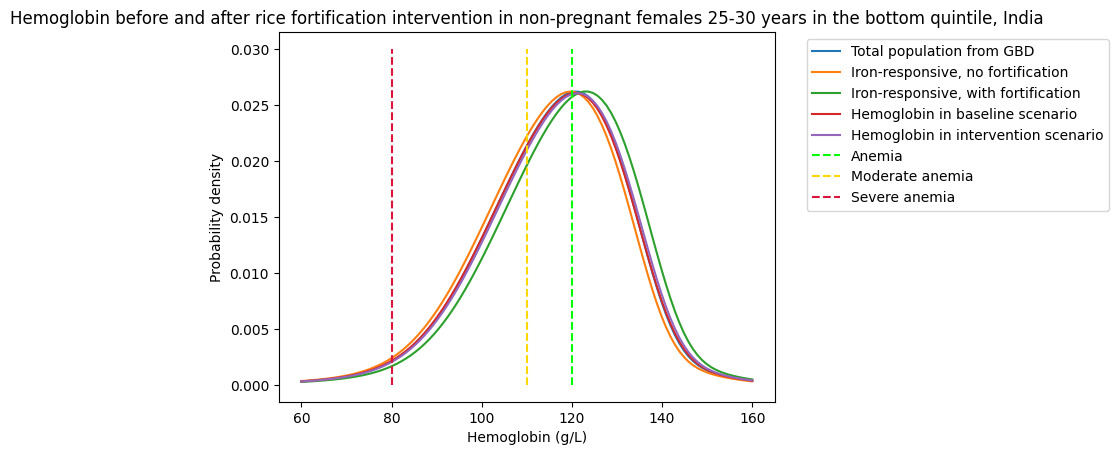

In [91]:
import matplotlib.pyplot as plt

x_values = np.linspace(60, 160, 100)
with np.errstate(under="ignore"):
    plt.plot(x_values, [total_population_pdf(x) for x in x_values], label="Total population from GBD")
    plt.plot(x_values, [iron_responsive_zero_fort_pdf(x) for x in x_values], label="Iron-responsive, no fortification")
    plt.plot(
        x_values,
        [iron_responsive_with_fort_pdf(x) for x in x_values],
        label="Iron-responsive, with fortification",
    )
    plt.plot(
        x_values,
        [baseline_pdf(x) for x in x_values],
        label="Hemoglobin in baseline scenario",
    )
    plt.plot(
        x_values,
        [intervention_pdf(x) for x in x_values],
        label="Hemoglobin in intervention scenario",
    )
    plt.vlines(
        thresholds.loc[(example_sex, example_age_start, example_age_end, 0)].hgb_upper_mild,
        0,
        0.03,
        linestyles="dashed",
        label="Anemia",
        color="lime",
    )
    plt.vlines(
        thresholds.loc[(example_sex, example_age_start, example_age_end, 0)].hgb_upper_moderate,
        0,
        0.03,
        linestyles="dashed",
        label="Moderate anemia",
        color="gold",
    )
    plt.vlines(
        thresholds.loc[(example_sex, example_age_start, example_age_end, 0)].hgb_upper_severe,
        0,
        0.03,
        linestyles="dashed",
        label="Severe anemia",
        color="crimson",
    )
    plt.xlabel("Hemoglobin (g/L)")
    plt.ylabel("Probability density")
    plt.title(
        f"Hemoglobin before and after {vehicle} fortification intervention in non-pregnant females 25-30 years in the bottom quintile, {location.title()}"
    )
    plt.legend(bbox_to_anchor=(1.05, 1))

In [92]:
(baseline_anemia - intervention_anemia).sort_values("anemic")

severe  \
sex  age_start age_end   wealth_quintile draw     scenario                     
Male 0.0       0.019178  1               draw_475 intervention  8.019537e-07   
                                         draw_47  intervention  5.496490e-07   
                                         draw_210 intervention  1.794782e-06   
                                         draw_381 intervention  2.966329e-07   
                                         draw_39  intervention  1.692063e-06   
...                                                                      ...   
     5.0       10.000000 5               draw_294 intervention  5.373511e-05   
     0.0       0.019178  5               draw_17  intervention  2.995812e-06   
                                         draw_464 intervention  9.783511e-07   
     5.0       10.000000 5               draw_19  intervention  1.658205e-05   
     0.0       0.019178  5               draw_89  intervention  6.168137e-07   

                                                                moderate  \
sex  age_start age_end   wealth_quintile draw     scenario                 
Male 0.0       0.019178  1               draw_475 intervention  0.047815   
                                         draw_47  intervention  0.047921   
                                         draw_210 intervention  0.044098   
                                         draw_381 intervention  0.045110   
                                         draw_39  intervention  0.043063   
...                                                                  ...   
     5.0       10.000000 5               draw_294 intervention  0.027606   
     0.0       0.019178  5               draw_17  intervention  0.015289   
                                         draw_464 intervention  0.015261   
     5.0       10.000000 5               draw_19  intervention  0.025564   
     0.0       0.019178  5               draw_89  intervention  0.011859   

                                                                    mild  \
sex  age_start age_end   wealth_quintile draw     scenario                 
Male 0.0       0.019178  1               draw_475 intervention -0.047673   
                                         draw_47  intervention -0.047742   
                                         draw_210 intervention -0.043916   
                                         draw_381 intervention -0.044790   
                                         draw_39  intervention -0.042731   
...                                                                  ...   
     5.0       10.000000 5               draw_294 intervention  0.017846   
     0.0       0.019178  5               draw_17  intervention  0.031808   
                                         draw_464 intervention  0.032305   
     5.0       10.000000 5               draw_19  intervention  0.026204   
     0.0       0.019178  5               draw_89  intervention  0.041465   

                                                                  anemic  
sex  age_start age_end   wealth_quintile draw     scenario                
Male 0.0       0.019178  1               draw_475 intervention  0.000143  
                                         draw_47  intervention  0.000179  
                                         draw_210 intervention  0.000183  
                                         draw_381 intervention  0.000320  
                                         draw_39  intervention  0.000333  
...                                                                  ...  
     5.0       10.000000 5               draw_294 intervention  0.045506  
     0.0       0.019178  5               draw_17  intervention  0.047100  
                                         draw_464 intervention  0.047567  
     5.0       10.000000 5               draw_19  intervention  0.051784  
     0.0       0.019178  5               draw_89  intervention  0.053324  

[125000 rows x 4 columns]

In [93]:
def anemia_to_yld_rates(anemia):
    disability_weights = pd.read_hdf(
        "/mnt/team/simulation_science/costeffectiveness/auxiliary_data/GBD_2021/02_processed_data/disability_weight/sequela/all/all.hdf"
    )
    disability_weights = (
        disability_weights[
            disability_weights.healthstate.isin(
                ["anemia_mild", "anemia_mod", "anemia_sev"]
            )
        ]
        .set_index("healthstate")
        .filter(like="draw_")
    )
    disability_weights.columns.name = "draw"
    disability_weights = (
        disability_weights.stack().rename("disability_weight").reset_index()
    )
    display(disability_weights)

    orig_index = anemia.index
    anemia = (
        anemia.reset_index()
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mild"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "mild_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mod"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "moderate_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_sev"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "severe_dw"}),
            validate="m:1",
        )
    )

    anemia["mild_yld_rate"] = anemia.mild * anemia.mild_dw
    anemia["moderate_yld_rate"] = anemia.moderate * anemia.moderate_dw
    anemia["severe_yld_rate"] = anemia.severe * anemia.severe_dw
    anemia["anemic_yld_rate"] = (
        anemia["mild_yld_rate"]
        + anemia["moderate_yld_rate"]
        + anemia["severe_yld_rate"]
    )

    return anemia.set_index(orig_index.names).filter(like="yld_rate")

In [94]:
zero_fort_anemia_yld_rates = anemia_to_yld_rates(zero_fort_anemia)
zero_fort_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    draw    wealth_quintile                  
Female 0.0       0.019178   draw_0  1                     0.000589   
                                    2                     0.000767   
                                    3                     0.000795   
                                    4                     0.000947   
                                    5                     0.001093   
...                                                            ...   
Male   95.0      125.000000 draw_99 1                     0.000890   
                                    2                     0.000889   
                                    3                     0.000878   
                                    4                     0.000898   
                                    5                     0.000944   

                                                     moderate_yld_rate  \
sex    age_start age_end    draw    wealth_quintile                      
Female 0.0       0.019178   draw_0  1                         0.044042   
                                    2                         0.039361   
                                    3                         0.038472   
                                    4                         0.034132   
                                    5                         0.029910   
...                                                                ...   
Male   95.0      125.000000 draw_99 1                         0.013164   
                                    2                         0.012954   
                                    3                         0.012740   
                                    4                         0.012793   
                                    5                         0.013019   

                                                     severe_yld_rate  \
sex    age_start age_end    draw    wealth_quintile                    
Female 0.0       0.019178   draw_0  1                       0.000824   
                                    2                       0.000649   
                                    3                       0.000714   
                                    4                       0.000571   
                                    5                       0.000378   
...                                                              ...   
Male   95.0      125.000000 draw_99 1                       0.030348   
                                    2                       0.029526   
                                    3                       0.029418   
                                    4                       0.028220   
                                    5                       0.025938   

                                                     anemic_yld_rate  
sex    age_start age_end    draw    wealth_quintile                   
Female 0.0       0.019178   draw_0  1                       0.045455  
                                    2                       0.040778  
                                    3                       0.039981  
                                    4                       0.035649  
                                    5                       0.031380  
...                                                              ...  
Male   95.0      125.000000 draw_99 1                       0.044402  
                                    2                       0.043369  
                                    3                       0.043036  
                                    4                       0.041911  
                                    5                       0.039902  

[125000 rows x 4 columns]

In [95]:
baseline_anemia_yld_rates = anemia_to_yld_rates(baseline_anemia)
baseline_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                     
Female 0.0       0.019178   1               draw_0        0.000667   
                            2               draw_0        0.000843   
                            3               draw_0        0.000861   
                            4               draw_0        0.000995   
                            5               draw_0        0.001115   
...                                                            ...   
Male   95.0      125.000000 1               draw_99       0.000897   
                            2               draw_99       0.000895   
                            3               draw_99       0.000883   
                            4               draw_99       0.000901   
                            5               draw_99       0.000946   

                                                     moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                         
Female 0.0       0.019178   1               draw_0            0.041961   
                            2               draw_0            0.037187   
                            3               draw_0            0.036496   
                            4               draw_0            0.032463   
                            5               draw_0            0.028960   
...                                                                ...   
Male   95.0      125.000000 1               draw_99           0.013015   
                            2               draw_99           0.012806   
                            3               draw_99           0.012609   
                            4               draw_99           0.012674   
                            5               draw_99           0.012947   

                                                     severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0          0.000748   
                            2               draw_0          0.000589   
                            3               draw_0          0.000654   
                            4               draw_0          0.000529   
                            5               draw_0          0.000361   
...                                                              ...   
Male   95.0      125.000000 1               draw_99         0.029218   
                            2               draw_99         0.028462   
                            3               draw_99         0.028479   
                            4               draw_99         0.027426   
                            5               draw_99         0.025531   

                                                     anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0          0.043376  
                            2               draw_0          0.038619  
                            3               draw_0          0.038011  
                            4               draw_0          0.033987  
                            5               draw_0          0.030436  
...                                                              ...  
Male   95.0      125.000000 1               draw_99         0.043129  
                            2               draw_99         0.042163  
                            3               draw_99         0.041971  
                            4               draw_99         0.041001  
                            5               draw_99         0.039424  

[125000 rows x 4 columns]

In [96]:
(
    baseline_anemia_yld_rates.loc[("Female", 25, 30, 1)].mean()
    - anemia_to_yld_rates(iron_responsive_with_fort_anemia)
    .loc[("Female", 25, 30, 1)]
    .mean()
) / baseline_anemia_yld_rates.loc[("Female", 25, 30, 1)].mean()

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate        0.047352
moderate_yld_rate    0.139993
severe_yld_rate      0.196505
anemic_yld_rate      0.145180
dtype: float64

In [97]:
intervention_anemia_yld_rates = anemia_to_yld_rates(intervention_anemia)
intervention_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw    scenario                      
Female 0.0       0.019178   1               draw_0  intervention       0.000717   
                            2               draw_0  intervention       0.000892   
                            3               draw_0  intervention       0.000910   
                            4               draw_0  intervention       0.001040   
                            5               draw_0  intervention       0.001160   
...                                                                         ...   
Male   95.0      125.000000 1               draw_99 intervention       0.000899   
                            2               draw_99 intervention       0.000897   
                            3               draw_99 intervention       0.000885   
                            4               draw_99 intervention       0.000904   
                            5               draw_99 intervention       0.000949   

                                                                  moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw    scenario                          
Female 0.0       0.019178   1               draw_0  intervention           0.040650   
                            2               draw_0  intervention           0.035798   
                            3               draw_0  intervention           0.035035   
                            4               draw_0  intervention           0.030888   
                            5               draw_0  intervention           0.027040   
...                                                                             ...   
Male   95.0      125.000000 1               draw_99 intervention           0.012963   
                            2               draw_99 intervention           0.012749   
                            3               draw_99 intervention           0.012544   
                            4               draw_99 intervention           0.012594   
                            5               draw_99 intervention           0.012816   

                                                                  severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw    scenario                        
Female 0.0       0.019178   1               draw_0  intervention         0.000700   
                            2               draw_0  intervention         0.000550   
                            3               draw_0  intervention         0.000609   
                            4               draw_0  intervention         0.000490   
                            5               draw_0  intervention         0.000329   
...                                                                           ...   
Male   95.0      125.000000 1               draw_99 intervention         0.028832   
                            2               draw_99 intervention         0.028052   
                            3               draw_99 intervention         0.028013   
                            4               draw_99 intervention         0.026894   
                            5               draw_99 intervention         0.024792   

                                                                  anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw    scenario                       
Female 0.0       0.019178   1               draw_0  intervention         0.042067  
                            2               draw_0  intervention         0.037240  
                            3               draw_0  intervention         0.036554  
                            4               draw_0  intervention         0.032418  
                            5               draw_0  intervention         0.028529  
...                                                                           ...  
Male   95.0      125.000000 1               draw_99 intervention         0.0

In [98]:
(baseline_anemia_yld_rates - intervention_anemia_yld_rates).sort_values(
    "anemic_yld_rate"
)

mild_yld_rate  \
sex    age_start age_end   wealth_quintile draw    scenario                      
Male   25.0      30.000000 5               draw_38 intervention       0.000007   
                           2               draw_38 intervention       0.000006   
                           4               draw_38 intervention       0.000006   
                           1               draw_38 intervention       0.000006   
                           3               draw_38 intervention       0.000006   
...                                                                        ...   
       0.0       0.019178  1               draw_39 intervention      -0.000168   
Female 0.5       1.000000  5               draw_45 intervention       0.000067   
Male   0.0       0.019178  1               draw_45 intervention      -0.000285   
Female 0.0       0.019178  4               draw_45 intervention      -0.000270   
                           5               draw_45 intervention      -0.000286   

                                                                 moderate_yld_rate  \
sex    age_start age_end   wealth_quintile draw    scenario                          
Male   25.0      30.000000 5               draw_38 intervention           0.000022   
                           2               draw_38 intervention           0.000024   
                           4               draw_38 intervention           0.000024   
                           1               draw_38 intervention           0.000026   
                           3               draw_38 intervention           0.000027   
...                                                                            ...   
       0.0       0.019178  1               draw_39 intervention           0.002866   
Female 0.5       1.000000  5               draw_45 intervention           0.002568   
Male   0.0       0.019178  1               draw_45 intervention           0.003097   
Female 0.0       0.019178  4               draw_45 intervention           0.003147   
                           5               draw_45 intervention           0.003807   

                                                                 severe_yld_rate  \
sex    age_start age_end   wealth_quintile draw    scenario                        
Male   25.0      30.000000 5               draw_38 intervention     3.283578e-06   
                           2               draw_38 intervention     3.720822e-06   
                           4               draw_38 intervention     3.835324e-06   
                           1               draw_38 intervention     3.703297e-06   
                           3               draw_38 intervention     4.481669e-06   
...                                                                          ...   
       0.0       0.019178  1               draw_39 intervention     3.443766e-07   
Female 0.5       1.000000  5               draw_45 intervention     1.659028e-04   
Male   0.0       0.019178  1               draw_45 intervention     7.002487e-07   
Female 0.0       0.019178  4               draw_45 intervention     2.404822e-05   
                           5               draw_45 intervention     1.898950e-05   

                                                                 anemic_yld_rate  
sex    age_start age_end   wealth_quintile draw    scenario                       
Male   25.0      30.000000 5               draw_38 intervention         0.000032  
                           2               draw_38 intervention         0.000034  
                           4               draw_38 intervention         0.000034  
                           1               draw_38 intervention         0.000035  
                           3               draw_38 intervention         0.000038  
...                                                                          ...  
       0.0       0.019178  1               draw_39 intervention         0.002698  
Female 0.5       1.000000  5           

In [99]:
assert (
    (baseline_anemia_yld_rates - intervention_anemia_yld_rates).anemic_yld_rate > 0
).all()

In [100]:
zero_fort_ylds = (
    zero_fort_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
zero_fort_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  1879.997788
                               2                  1491.294886
                               3                  1302.492734
                               4                  1106.577438
                               5                   791.080846
                                                     ...     
Male    95.0       125.000000  1                   852.809673
                               2                   869.399486
                               3                   890.875157
                               4                   914.644375
                               5                  1073.065222
Length: 250, dtype: float64

In [101]:
baseline_ylds = (
    baseline_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
baseline_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  1800.159795
                               2                  1419.980700
                               3                  1244.664230
                               4                  1060.830730
                               5                   770.256104
                                                     ...     
Male    95.0       125.000000  1                   827.887942
                               2                   844.738449
                               3                   868.381263
                               4                   894.401344
                               5                  1059.957791
Length: 250, dtype: float64

In [102]:
intervention_ylds = (
    intervention_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
intervention_ylds

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    1749.871159
                               2                intervention    1374.409092
                               3                intervention    1201.904545
                               4                intervention    1017.652998
                               5                intervention     728.193297
                                                                   ...     
Male    95.0       125.000000  1                intervention     819.382420
                               2                intervention     835.242447
                               3                intervention     857.220097
                               4                intervention     880.819996
                               5                intervention    1036.201277
Length: 250, dtype: float64

In [103]:
(
    baseline_ylds.loc[("Female", 25, 30, 1)].mean()
    - intervention_ylds.loc[("Female", 25, 30, 1)].mean()
)

5855.746988820931

In [104]:
(
    baseline_ylds.groupby(["wealth_quintile"]).sum()
    - intervention_ylds.groupby(["wealth_quintile"]).sum()
)

wealth_quintile
1    135125.540609
2    128907.468396
3    140289.703170
4    145770.480311
5    178710.308713
dtype: float64

In [105]:
ylds = pd.concat(
    [
        zero_fort_ylds.rename("value").reset_index().assign(scenario="zero"),
        baseline_ylds.rename("value").reset_index().assign(scenario="baseline"),
        intervention_ylds.rename("value").reset_index().assign(scenario="intervention"),
    ],
    ignore_index=True,
)
ylds

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,1879.997788,zero
1,Female,0.0,0.019178,2,1491.294886,zero
2,Female,0.0,0.019178,3,1302.492734,zero
3,Female,0.0,0.019178,4,1106.577438,zero
4,Female,0.0,0.019178,5,791.080846,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,819.382420,intervention
746,Male,95.0,125.000000,2,835.242447,intervention
747,Male,95.0,125.000000,3,857.220097,intervention
748,Male,95.0,125.000000,4,880.819996,intervention


In [106]:
results_dir = (
    f"./results/{vehicle.lower()}/{location.lower()}"
)

In [107]:
path = f"{results_dir}/ylds.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
ylds.to_parquet(path)

In [108]:
zero_fort_anemia_prevalence = zero_fort_anemia["anemic"].unstack("draw").mean(axis=1)
zero_fort_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.971149
                               2                  0.956037
                               3                  0.949217
                               4                  0.927571
                               5                  0.907860
                                                    ...   
Male    95.0       125.000000  1                  0.795881
                               2                  0.783839
                               3                  0.775056
                               4                  0.771018
                               5                  0.768660
Length: 250, dtype: float64

In [109]:
baseline_anemia_prevalence = baseline_anemia["anemic"].unstack("draw").mean(axis=1)
baseline_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.963938
                               2                  0.945304
                               3                  0.938272
                               4                  0.915193
                               5                  0.899080
                                                    ...   
Male    95.0       125.000000  1                  0.784474
                               2                  0.772673
                               3                  0.765040
                               4                  0.762265
                               5                  0.763871
Length: 250, dtype: float64

In [110]:
zero_fort_anemia_cases = zero_fort_anemia_prevalence.mul(non_pregnant_pop, axis=0)
zero_fort_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  48217.239507
                               2                  41659.886110
                               3                  36724.587080
                               4                  33801.454868
                               5                  26511.853939
                                                      ...     
Male    95.0       125.000000  1                  12078.843002
                               2                  12422.676510
                               3                  12687.806516
                               4                  13311.863178
                               5                  16364.376513
Length: 250, dtype: float64

In [111]:
zero_fort_anemia_cases.sum() / non_pregnant_pop.sum()

0.4360801900193162

In [112]:
baseline_anemia_cases = baseline_anemia_prevalence.mul(non_pregnant_pop, axis=0)
baseline_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  47859.222861
                               2                  41192.223508
                               3                  36301.127585
                               4                  33350.380230
                               5                  26255.469861
                                                      ...     
Male    95.0       125.000000  1                  11905.725485
                               2                  12245.719036
                               3                  12523.843057
                               4                  13160.751121
                               5                  16262.415037
Length: 250, dtype: float64

In [113]:
baseline_anemia_cases.sum() / non_pregnant_pop.sum()

0.41368759870173777

In [114]:
baseline_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.465299
2    0.427506
3    0.416714
4    0.392831
5    0.367576
dtype: float64

In [115]:
intervention_anemia_prevalence = (
    intervention_anemia["anemic"].unstack("draw").mean(axis=1)
)
intervention_anemia_prevalence

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    0.959396
                               2                intervention    0.938446
                               3                intervention    0.930179
                               4                intervention    0.903509
                               5                intervention    0.881347
                                                                  ...   
Male    95.0       125.000000  1                intervention    0.780581
                               2                intervention    0.768374
                               3                intervention    0.760070
                               4                intervention    0.756393
                               5                intervention    0.755191
Length: 250, dtype: float64

In [116]:
anemia_prevalence = pd.concat(
    [
        zero_fort_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="zero"),
        baseline_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="baseline"),
        intervention_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="intervention"),
    ],
    ignore_index=True,
)
anemia_prevalence

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,0.971149,zero
1,Female,0.0,0.019178,2,0.956037,zero
2,Female,0.0,0.019178,3,0.949217,zero
3,Female,0.0,0.019178,4,0.927571,zero
4,Female,0.0,0.019178,5,0.907860,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,0.780581,intervention
746,Male,95.0,125.000000,2,0.768374,intervention
747,Male,95.0,125.000000,3,0.760070,intervention
748,Male,95.0,125.000000,4,0.756393,intervention


In [117]:
path = f"{results_dir}/anemia_prevalence.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_prevalence.to_parquet(path)

In [118]:
intervention_anemia_cases = intervention_anemia_prevalence.mul(non_pregnant_pop, axis=0)
intervention_anemia_cases

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    47633.714076
                               2                intervention    40893.375023
                               3                intervention    35988.012196
                               4                intervention    32924.636364
                               5                intervention    25737.613078
                                                                    ...     
Male    95.0       125.000000  1                intervention    11846.642318
                               2                intervention    12177.579630
                               3                intervention    12442.486605
                               4                intervention    13059.367809
                               5                intervention    16077.615350
Length: 250, dtype: float64

In [119]:
intervention_anemia_cases.sum() / non_pregnant_pop.sum()

0.40005516258038526

In [120]:
intervention_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.453674
2    0.415867
3    0.403931
4    0.379009
5    0.349371
dtype: float64

In [121]:
(
    baseline_anemia_cases.groupby(["wealth_quintile"]).sum()
    - intervention_anemia_cases.groupby(["wealth_quintile"]).sum()
).map(lambda x: f"{round(x):,.0f}")

wealth_quintile
1    3,188,257
2    3,230,484
3    3,570,030
4    3,876,194
5    5,127,257
dtype: object

In [122]:
anemia_cases = pd.concat(
    [
        zero_fort_anemia_cases.rename("value").reset_index().assign(scenario="zero"),
        baseline_anemia_cases.rename("value").reset_index().assign(scenario="baseline"),
        intervention_anemia_cases.rename("value")
        .reset_index()
        .assign(scenario="intervention"),
    ],
    ignore_index=True,
)
anemia_cases

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,48217.239507,zero
1,Female,0.0,0.019178,2,41659.886110,zero
2,Female,0.0,0.019178,3,36724.587080,zero
3,Female,0.0,0.019178,4,33801.454868,zero
4,Female,0.0,0.019178,5,26511.853939,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,11846.642318,intervention
746,Male,95.0,125.000000,2,12177.579630,intervention
747,Male,95.0,125.000000,3,12442.486605,intervention
748,Male,95.0,125.000000,4,13059.367809,intervention


In [123]:
path = f"{results_dir}/anemia_cases.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_cases.to_parquet(path)